<a href="https://colab.research.google.com/github/Wandersonelias/notebooks/blob/master/Pratica_03_UC3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas padrão para Manipulação de dados e arquivos

In [ ]:

import pandas as pd
import numpy as np
import requests
import os
import time
import joblib
#Bibliotecas de plotagem de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay,precision_score,recall_score, classification_report, f1_score

# Bibliotecas responsáveis de pelo pipe de Machine Learning
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Modelo que será usado para classificação
from xgboost import XGBClassifier


# Funções principais do sistema

In [ ]:
#Criando uma session para facilitar o download
session = requests.session()


In [ ]:
#Função para baixar os dados do github e gravar como csv
def carregar_dados(url_base,filename):
  if os.path.isfile(filename):
    print("Arquivo existe - carregando para o Dataframe")
    df = pd.read_csv(filename)
  else:
    response = session.get(f"{url_base}/{filename}")
    if response.status_code == 200:
      print("Conectado com sucesso!")
      with open(f'{filename}','wb') as filewrite:
        for chunck in response.iter_content(chunk_size=128):
          filewrite.write(chunck)
        print("Gravado com sucesso!!")

    else:
      raise response.raise_for_status

  df = pd.read_csv(filename)
  return df

def df_prep(dados,target):
  """ Função responsável pelo tratamento dos dados"""
  #Separando o dados para treino no dataset
  coluna_alvo = target

  if coluna_alvo in dados.columns:
    print(f"Coluna alvo '{coluna_alvo}' localizada e DataFrame divido para o split de treino e teste.")
    X = dados.drop(coluna_alvo,axis=1)
    y = dados[coluna_alvo]
    return X, y # Retorna X e y
  else:
    print(f"Erro: Coluna alvo '{coluna_alvo}' não encontrada no DataFrame.")
    return None, None # Retorna None se a coluna não for encontrada



# Carregando dados

In [ ]:
df = carregar_dados("https://raw.githubusercontent.com/Wandersonelias/Datasets/refs/heads/master","flights_delays_120.csv")

Arquivo existe - carregando para o Dataframe


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   airline         120 non-null    object
 1   origin          120 non-null    object
 2   destination     120 non-null    object
 3   departure_hour  120 non-null    int64 
 4   day_of_week     120 non-null    int64 
 5   weather         120 non-null    object
 6   delayed         120 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 6.7+ KB


# Preparando os dados

In [ ]:
X, y = df_prep(df,"delayed")

Coluna alvo 'delayed' localizada e DataFrame divido para o split de treino e teste.


In [ ]:
# Usando o numpy com o pandas para separar as colunas numerias e categoricas
categoricas = X.select_dtypes(include='object').columns.tolist()
numericas = X.select_dtypes(include=np.number).columns.to_list()
print (f"Colunas categóricas identificadas:{categoricas}")
print (f"Colunas numéricas identificadas:{numericas}")

Colunas categóricas identificadas:['airline', 'origin', 'destination', 'weather']
Colunas numéricas identificadas:['departure_hour', 'day_of_week']


# Separando os dados em Teste e Treinamento 80% e 20%

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=15)
print(f"Divisão dos dados: {len(y_train)} para treino, {len(y_test)} para teste em uma amostra de 120 registros.")

Divisão dos dados: 96 para treino, 24 para teste em uma amostra de 120 registros.


# Pré-processamento de colunas transformado as colunas categorias em numericas, usando o ColumnTransformer invés de dois processo separados

In [ ]:
pre_processador = ColumnTransformer([
    ("categoricas",OneHotEncoder(handle_unknown="ignore"),categoricas),
    ("numericas","passthrough",numericas)
])

# Configurando o XGBoostClassifier

Usando os seguintes hiperparamentros:

* **n_estimators** = 400: Define o número de árvores de decisão a serem construídas sequencialmente (rodadas de boosting).

* **learning_rate** = 0.08: Controla o peso dado a cada nova árvore, ou seja, a taxa na qual o modelo aprende.

* **max_depth** = 9: Define a profundidade máxima de cada árvore individual no conjunto.

* **subsample** = 0.9: Fração das amostras de treinamento (linhas) a serem usadas para construir cada árvore. Usar 90% (0.9) dos dados de forma aleatória ajuda a reduzir a variância do modelo (semelhante ao bagging).
    
* **colsample_bytree**=0.9: Fração das features/variáveis (colunas) a serem amostradas aleatoriamente para construir cada árvore.
    
* **eval_metric** = "logloss": Métrica de avaliação usada para monitorar o desempenho durante o treinamento (especialmente em validação cruzada).

* **random_state** = 15: Define a semente para o gerador de números aleatórios.

In [ ]:
modelo = XGBClassifier(
    n_estimators = 400,
    learning_rate = 0.08,
    max_depth = 9,
    subsample = 0.9,
    colsample_bytree=0.9,
    eval_metric = "logloss",
    random_state = 15
)

# Pipeline de Treinamento

In [ ]:
#Criação do Pipeline configurando com os dados devidamente pre-processado e trados
pipeline = Pipeline([
    ("prep",pre_processador),
    ("xgb",modelo)
])

#Treinamento do pipeline
pipeline.fit(X_train,y_train)
print(f"Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [ ]:
probabilidades = pipeline.predict_proba(X_test)[:, 1]
print(probabilidades)

[9.7763968e-01 2.7503273e-02 3.9408643e-02 9.9249470e-01 7.2130740e-01
 1.9634364e-02 9.2086208e-01 9.8992455e-01 8.6205041e-01 9.4357193e-01
 2.0478476e-02 4.9350876e-04 3.1922626e-01 8.2455168e-04 7.5068915e-01
 2.7644815e-02 8.8021421e-01 3.1529609e-02 4.0511787e-02 1.7549066e-02
 9.2487723e-01 9.3092334e-01 5.3047907e-01 3.8749445e-02]


In [ ]:
predicao = pipeline.predict(X_test)
print(predicao)

[1 0 0 1 1 0 1 1 1 1 0 0 0 0 1 0 1 0 0 0 1 1 1 0]


# Métricas

## Matriz de confusão

[[12  2]
 [ 0 10]]
------------------------------------------------------------------
TP: 12 | FP: 0 | FN: 2 | TN: 10


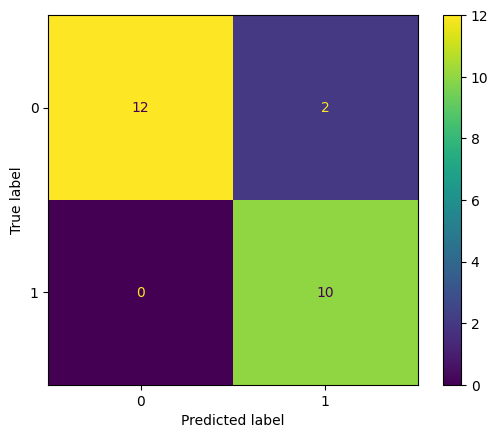

In [ ]:

# Matriz de confusão
cm = confusion_matrix(y_test,predicao)
print(cm)
print("------------------------------------------------------------------")
print(f"TP: {cm[0][0]} | FP: {cm[1][0]} | FN: {cm[0][1]} | TN: {cm[1][1]}")
matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=pipeline.classes_)
matrix_display.plot()
plt.show()


## Acurácia

In [ ]:
acuracia = accuracy_score(y_test,predicao)
print(f"O percenteual de acurária do modelo é de {acuracia:.2f}%")

O percenteual de acurária do modelo é de 0.92%


## Recall - Sensibilidade

In [ ]:
sencibilidade = recall_score(y_test,predicao)
print(f"O nivel de sensibilidade do modelo é de {sencibilidade:.2f}%")

O nivel de sensibilidade do modelo é de 1.00%


In [ ]:
especificidade = recall_score(y_test,predicao,pos_label=0)
print(f"O nivel de especificade do modelo é de {especificidade:.2f}%")

O nivel de especificade do modelo é de 0.86%


## Precisão

In [ ]:
precisao = precision_score(y_test,predicao)
print(f"O nivel de precisão do modelo é de {precisao:.2f}%")

O nivel de precisão do modelo é de 0.83%


# F1 - Score

In [ ]:
print(f"F1-Score: {f1_score(y_test, predicao, zero_division=0):.4f}")

F1-Score: 0.9091


## Curva ROC AUC

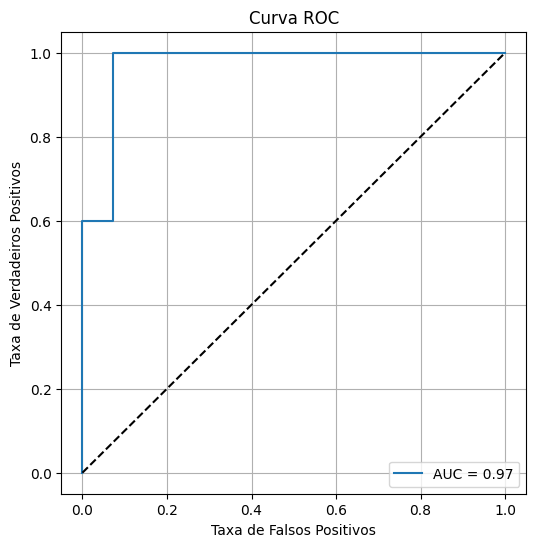

In [ ]:
# Probabilidades previstas pelo modelo (necessárias para ROC)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Calculando FPR, TPR e thresholds para Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculando a AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plotando a Curva ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # Linha diagonal (modelo aleatório)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## AUC Score

In [ ]:
auc_score = roc_auc_score(y_test,y_prob)
print(f"O nivel de auc_roc do modelo é de {auc_score:.2f}%")

O nivel de auc_roc do modelo é de 0.97%


# Relatório de Classificação

In [ ]:
print("Relatório de classificação: \n", classification_report(y_test,predicao))

Relatório de classificação: 
               precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       0.83      1.00      0.91        10

    accuracy                           0.92        24
   macro avg       0.92      0.93      0.92        24
weighted avg       0.93      0.92      0.92        24



# Preparando a implantação do modelo usando a Joblib

In [ ]:
arquivo_modelo = "modelo_xgb_deploy_pipeline.joblib"

#Salvando o pipeline completo dentro da joblib

try:
  joblib.dump(pipeline,arquivo_modelo)
  print("O pipeline foi adicionado como sucesso no aquivo ", arquivo_modelo)

  #Preparando o modelo para carregar a simulaçaõ de ambiente de produção
  modelo_deploy = joblib.load(arquivo_modelo)
  print("Modelo de simulação de produção carregado",modelo_deploy)
except Exception as e:
  print(f"Erro ao salvar/carregar o modelo: {e}")

  # Vamos definir o nosso modelo_deploy como nosso pipeline treinado se o salvamento da joblib falhar
  modelo_deploy = pipeline




O pipeline foi adicionado como sucesso no aquivo  modelo_xgb_deploy_pipeline.joblib
Modelo de simulação de produção carregado Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['airline', 'origin',
                                                   'destination', 'weather']),
                                                 ('numericas', 'passthrough',
                                                  ['departure_hour',
                                                   'day_of_week'])])),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.9...
                               feature_types=None, feature_weights=None,
                 

# Simulações de predições em tempo real


In [ ]:
#Simulando registros aleatórios dentro do conjunto de teste para fazer um input de dados
registro = X_test.sample(1,random_state=42).copy()
y_real = y_test.loc[registro.index[0]] #Pegando um valor real

print("Analisando amostras")
print("-"*70)
print(registro)
print("-"*70)
print(y_real)
print("-"*70)

#Fazer a predição
probas_rt = modelo_deploy.predict_proba(registro)[:,1]
predicao_rt = (probas_rt[0] >= 0.5).astype(int)


#Exibir os resultados
print(f"\nProbabilidade de atraso (Classe 1): {probas_rt[0]:.4f}")
print(f"Predição Binária: {'Atraso' if predicao_rt == 1 else 'No Atraso'} (Valor: {y_real})")
print(f"Predição Correta? {predicao_rt == y_real}")

Analisando amostras
----------------------------------------------------------------------
    airline origin destination  departure_hour  day_of_week weather
60  FlyFast    GRU         BEL               6            1     Fog
----------------------------------------------------------------------
1
----------------------------------------------------------------------

Probabilidade de atraso (Classe 1): 0.8621
Predição Binária: Atraso (Valor: 1)
Predição Correta? True


# Simular inferência em Conjunto de Registros - Batch | Lote

In [ ]:
lote_registros = X_test.head(100).copy()
lote_y_reais = y_test.head(100).copy()

#Pega usando o head os primeiros 100 registros do dataframe e faz uma copia
print("\n--- Inferência em Lote (100 registros) ---")
print(f"Processando lote de {len(lote_registros)} registros...")

# O método 'predict_proba' é vetorizado (rápido) para conjuntos grandes
probas_batch = modelo_deploy.predict_proba(lote_registros)[:,1]
print("Predições antes da coversão Binária\n",probas_batch)

# Fazendo a convesão dos resultado onde a probabilidade de acerto é maior que
# 50% converto em interio com o valor e 1 que não for em valor 0, criando assim
# uma listagem binaria de predições
predicoes_batch = (probas_batch >= 0.5).astype(int)




#Analise de Resultados do Lote
df_resultados_batch = pd.DataFrame({
    'Prob_Atraso': probas_batch,
    'Predicao_Binaria': predicoes_batch,
    'Real':lote_y_reais.values
})

#Exibir o resumo e avaliação
acuracia_batch = accuracy_score(df_resultados_batch['Real'], df_resultados_batch['Predicao_Binaria'])
print(f"\nResumo da Inferência em Lote:")
print(f"Acurácia do Lote: {acuracia_batch:.4f}")
print("Distribuição de Predições (0=No Atraso):\n", df_resultados_batch['Predicao_Binaria'].value_counts())
print("\nPrimeiros 5 resultados do Lote:\n", df_resultados_batch.head())



--- Inferência em Lote (100 registros) ---
Processando lote de 24 registros...
Predições antes da coversão Binária
 [9.7763968e-01 2.7503273e-02 3.9408643e-02 9.9249470e-01 7.2130740e-01
 1.9634364e-02 9.2086208e-01 9.8992455e-01 8.6205041e-01 9.4357193e-01
 2.0478476e-02 4.9350876e-04 3.1922626e-01 8.2455168e-04 7.5068915e-01
 2.7644815e-02 8.8021421e-01 3.1529609e-02 4.0511787e-02 1.7549066e-02
 9.2487723e-01 9.3092334e-01 5.3047907e-01 3.8749445e-02]

Resumo da Inferência em Lote:
Acurácia do Lote: 0.9167
Distribuição de Predições (0=No Atraso):
 Predicao_Binaria
1    12
0    12
Name: count, dtype: int64

Primeiros 5 resultados do Lote:
    Prob_Atraso  Predicao_Binaria  Real
0     0.977640                 1     1
1     0.027503                 0     0
2     0.039409                 0     0
3     0.992495                 1     1
4     0.721307                 1     1


# Analises finais

In [ ]:
print("\n\n##################################")
print("### CONCLUSÕES DA IMPLANTAÇÃO E INFERÊNCIA ###")
print("##################################")

#Comparação Tempo Real vs. Batch
print("\n1. Consistência entre Tempo Real e Lote:")
print("- A *lógica* de predição é idêntica para os dois modos, pois ambos usam o mesmo Pipeline.")
print("- A principal diferença é a *velocidade* e o *formato* de entrada/saída.")
print("  - **Tempo Real:** Recebe 1 registro, retorna 1 predição. Requer baixa latência (rápido).")
print("  - **Lote:** Recebe N registros, retorna N predições. Focado em *throughput* (alto volume).")
print("- A acurácia do lote (100 registros): {:.4f} (Em linha com o desempenho geral do Teste).".format(acuracia_batch))

# Interpretação do Modelo e Métricas
print("\n2. Interpretação das Métricas de Teste:")
print(f"- **AUC ({auc_score}):** Um valor alto (próximo de 1) indica que o modelo tem uma excelente capacidade de ranquear corretamente as instâncias (separar voos com e sem atraso).")
print("- **Recall (Sensibilidade):** Indica a proporção de voos *reais* atrasados que o modelo conseguiu capturar. Um Recall alto é crucial se a prioridade for evitar a perda de atrasos.")
print("- **Precisão:** Indica a proporção de voos que o modelo *previu* como atrasados que de fato atrasaram. Uma Precisão alta reduz o número de 'alarmes falsos'.")
print("- O F1-Score busca um equilíbrio entre Precisão e Recall.")

# Conclusões da Atividade
print("\n3. Resumo da Atividade (Google Colab):")
print("- A utilização do `Pipeline` do Scikit-learn simplificou o processo de `fit` e `transform`, aplicando o pré-processamento e o modelo em uma única etapa.")
print("- O salvamento via `joblib.dump` garantiu que todo o fluxo (pré-processador e XGBoost) fosse salvo, garantindo a reprodutibilidade na fase de implantação.")
print("- O processo de inferência foi validado em ambos os cenários, mostrando que o modelo implantado está pronto para uso em produção.")
print("##################################")



##################################
### CONCLUSÕES DA IMPLANTAÇÃO E INFERÊNCIA ###
##################################

1. Consistência entre Tempo Real e Lote:
- A *lógica* de predição é idêntica para os dois modos, pois ambos usam o mesmo Pipeline.
- A principal diferença é a *velocidade* e o *formato* de entrada/saída.
  - **Tempo Real:** Recebe 1 registro, retorna 1 predição. Requer baixa latência (rápido).
  - **Lote:** Recebe N registros, retorna N predições. Focado em *throughput* (alto volume).
- A acurácia do lote (100 registros): 0.9167 (Em linha com o desempenho geral do Teste).

2. Interpretação das Métricas de Teste:
- **AUC (0.9714285714285714):** Um valor alto (próximo de 1) indica que o modelo tem uma excelente capacidade de ranquear corretamente as instâncias (separar voos com e sem atraso).
- **Recall (Sensibilidade):** Indica a proporção de voos *reais* atrasados que o modelo conseguiu capturar. Um Recall alto é crucial se a prioridade for evitar a perda de atrasos.
